# QUWI PyTorch Dataset and DataLoader

This notebook converts the validated QUWI preprocessing pipeline into a reusable PyTorch Dataset and DataLoader workflow.

## Goals

- Load image paths and writer-disjoint split metadata
- Implement a custom PyTorch Dataset
- Apply aspect-ratio-preserving resize and white padding
- Return image tensors with writer, script, and text-condition labels
- Build separate development-train, validation, and official-test DataLoaders
- Verify batch shapes, labels, and writer separation
- Test safe DataLoader settings for the available GPU and memory

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

QUWI_ROOT = Path.home() / "Documents" / "Handwriting" / "QUWI"
IMAGE_DIR = QUWI_ROOT / "extracted" / "images"
SPLIT_PATH = PROJECT_ROOT / "splits" / "quwi_writer_disjoint_split_seed42.csv"
CONFIG_PATH = PROJECT_ROOT / "reports" / "preprocessing" / "quwi_preprocessing_config_384.json"

split_df = pd.read_csv(SPLIT_PATH)

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    preprocessing_config = json.load(file)

print("Project root:", PROJECT_ROOT)
print("Image directory exists:", IMAGE_DIR.exists())
print("Split rows:", len(split_df))
print("Target size:", preprocessing_config["target_size"])
print("Output mode:", preprocessing_config["output_mode"])
print("Experiment splits:", split_df["experiment_split"].value_counts().to_dict())

Project root: /home/arijit/Documents/handwriting-cross-script-research
Image directory exists: True
Split rows: 1900
Target size: [384, 384]
Output mode: RGB
Experiment splits: {'development_train': 904, 'official_test': 772, 'validation': 224}


In [3]:
TARGET_SIZE = tuple(preprocessing_config["target_size"])
PADDING_VALUE = tuple(preprocessing_config["padding_value"])

LANGUAGE_TO_LABEL = {
    "Arabic": 0,
    "English": 1,
}

def resize_with_padding(image, target_size=TARGET_SIZE):
    image = image.convert("RGB")

    resized_image = ImageOps.contain(
        image,
        target_size,
        method=Image.Resampling.LANCZOS,
    )

    canvas = Image.new(
        "RGB",
        target_size,
        PADDING_VALUE,
    )

    left = (target_size[0] - resized_image.width) // 2
    top = (target_size[1] - resized_image.height) // 2

    canvas.paste(resized_image, (left, top))

    return canvas


with Image.open(IMAGE_DIR / "0001_1.jpg") as image:
    processed_image = resize_with_padding(image)

processed_tensor = TF.to_tensor(processed_image)

print("Processed size:", processed_image.size)
print("Processed mode:", processed_image.mode)
print("Tensor shape:", processed_tensor.shape)
print("Tensor dtype:", processed_tensor.dtype)
print("Tensor range:", processed_tensor.min().item(), "to", processed_tensor.max().item())

Processed size: (384, 384)
Processed mode: RGB
Tensor shape: torch.Size([3, 384, 384])
Tensor dtype: torch.float32
Tensor range: 0.239215686917305 to 1.0


In [4]:
class QUWIDataset(Dataset):
    def __init__(
        self,
        metadata,
        image_dir,
        target_size=TARGET_SIZE,
    ):
        self.metadata = metadata.reset_index(drop=True).copy()
        self.image_dir = Path(image_dir)
        self.target_size = target_size

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]
        image_path = self.image_dir / row["filename"]

        with Image.open(image_path) as image:
            processed_image = resize_with_padding(
                image,
                target_size=self.target_size,
            )

        image_tensor = TF.to_tensor(processed_image)

        return {
            "image": image_tensor,
            "writer_id": torch.tensor(
                int(row["writer"]),
                dtype=torch.long,
            ),
            "page_id": torch.tensor(
                int(row["page_id"]),
                dtype=torch.long,
            ),
            "language_label": torch.tensor(
                LANGUAGE_TO_LABEL[row["language"]],
                dtype=torch.long,
            ),
            "same_text": torch.tensor(
                int(row["same_text"]),
                dtype=torch.long,
            ),
            "filename": row["filename"],
            "language": row["language"],
            "experiment_split": row["experiment_split"],
        }

In [5]:
train_df = split_df[
    split_df["experiment_split"] == "development_train"
].copy()

validation_df = split_df[
    split_df["experiment_split"] == "validation"
].copy()

test_df = split_df[
    split_df["experiment_split"] == "official_test"
].copy()

train_dataset = QUWIDataset(
    train_df,
    IMAGE_DIR,
)

validation_dataset = QUWIDataset(
    validation_df,
    IMAGE_DIR,
)

test_dataset = QUWIDataset(
    test_df,
    IMAGE_DIR,
)

sample = train_dataset[0]

print("Train samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

print("\nSample keys:", list(sample.keys()))
print("Filename:", sample["filename"])
print("Image shape:", sample["image"].shape)
print("Writer ID:", sample["writer_id"].item())
print("Page ID:", sample["page_id"].item())
print("Language:", sample["language"])
print("Language label:", sample["language_label"].item())
print("Same-text label:", sample["same_text"].item())
print("Experiment split:", sample["experiment_split"])

Train samples: 904
Validation samples: 224
Test samples: 772

Sample keys: ['image', 'writer_id', 'page_id', 'language_label', 'same_text', 'filename', 'language', 'experiment_split']
Filename: 0001_1.jpg
Image shape: torch.Size([3, 384, 384])
Writer ID: 1
Page ID: 1
Language: Arabic
Language label: 0
Same-text label: 0
Experiment split: development_train


In [6]:
train_writers = set(train_df["writer"])
validation_writers = set(validation_df["writer"])
test_writers = set(test_df["writer"])

print("Train writers:", len(train_writers))
print("Validation writers:", len(validation_writers))
print("Test writers:", len(test_writers))
print("Train-validation overlap:", len(train_writers & validation_writers))
print("Train-test overlap:", len(train_writers & test_writers))
print("Validation-test overlap:", len(validation_writers & test_writers))

assert len(train_writers) == 226
assert len(validation_writers) == 56
assert len(test_writers) == 193
assert not train_writers & validation_writers
assert not train_writers & test_writers
assert not validation_writers & test_writers

Train writers: 226
Validation writers: 56
Test writers: 193
Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [7]:
BATCH_SIZE = 8
NUM_WORKERS = 0

generator = torch.Generator()
generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_batch = next(iter(train_loader))

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("Image batch shape:", train_batch["image"].shape)
print("Writer-ID shape:", train_batch["writer_id"].shape)
print("Page-ID shape:", train_batch["page_id"].shape)
print("Language-label shape:", train_batch["language_label"].shape)
print("Same-text shape:", train_batch["same_text"].shape)
print("Filenames:", train_batch["filename"])
print("Pinned-memory enabled:", torch.cuda.is_available())

assert train_batch["image"].shape == (8, 3, 384, 384)
assert train_batch["writer_id"].shape == (8,)
assert torch.isfinite(train_batch["image"]).all()

Train batches: 113
Validation batches: 28
Test batches: 97
Image batch shape: torch.Size([8, 3, 384, 384])
Writer-ID shape: torch.Size([8])
Page-ID shape: torch.Size([8])
Language-label shape: torch.Size([8])
Same-text shape: torch.Size([8])
Filenames: ['0078_1.jpg', '0193_4.jpg', '0198_3.jpg', '0208_3.jpg', '0170_1.jpg', '0061_2.jpg', '0060_1.jpg', '0153_1.jpg']
Pinned-memory enabled: True


In [8]:
batch_metadata_df = pd.DataFrame(
    {
        "filename": list(train_batch["filename"]),
        "writer_id": train_batch["writer_id"].tolist(),
        "page_id": train_batch["page_id"].tolist(),
        "language": list(train_batch["language"]),
        "language_label": train_batch["language_label"].tolist(),
        "same_text": train_batch["same_text"].tolist(),
        "experiment_split": list(train_batch["experiment_split"]),
    }
)

display(batch_metadata_df)

,filename,writer_id,page_id,language,language_label,same_text,experiment_split
0,0078_1.jpg,78,1,Arabic,0,0,development_train
1,0193_4.jpg,193,4,English,1,1,development_train
2,0198_3.jpg,198,3,English,1,0,development_train
3,0208_3.jpg,208,3,English,1,0,development_train
4,0170_1.jpg,170,1,Arabic,0,0,development_train
5,0061_2.jpg,61,2,Arabic,0,1,development_train
6,0060_1.jpg,60,1,Arabic,0,0,development_train
7,0153_1.jpg,153,1,Arabic,0,0,development_train


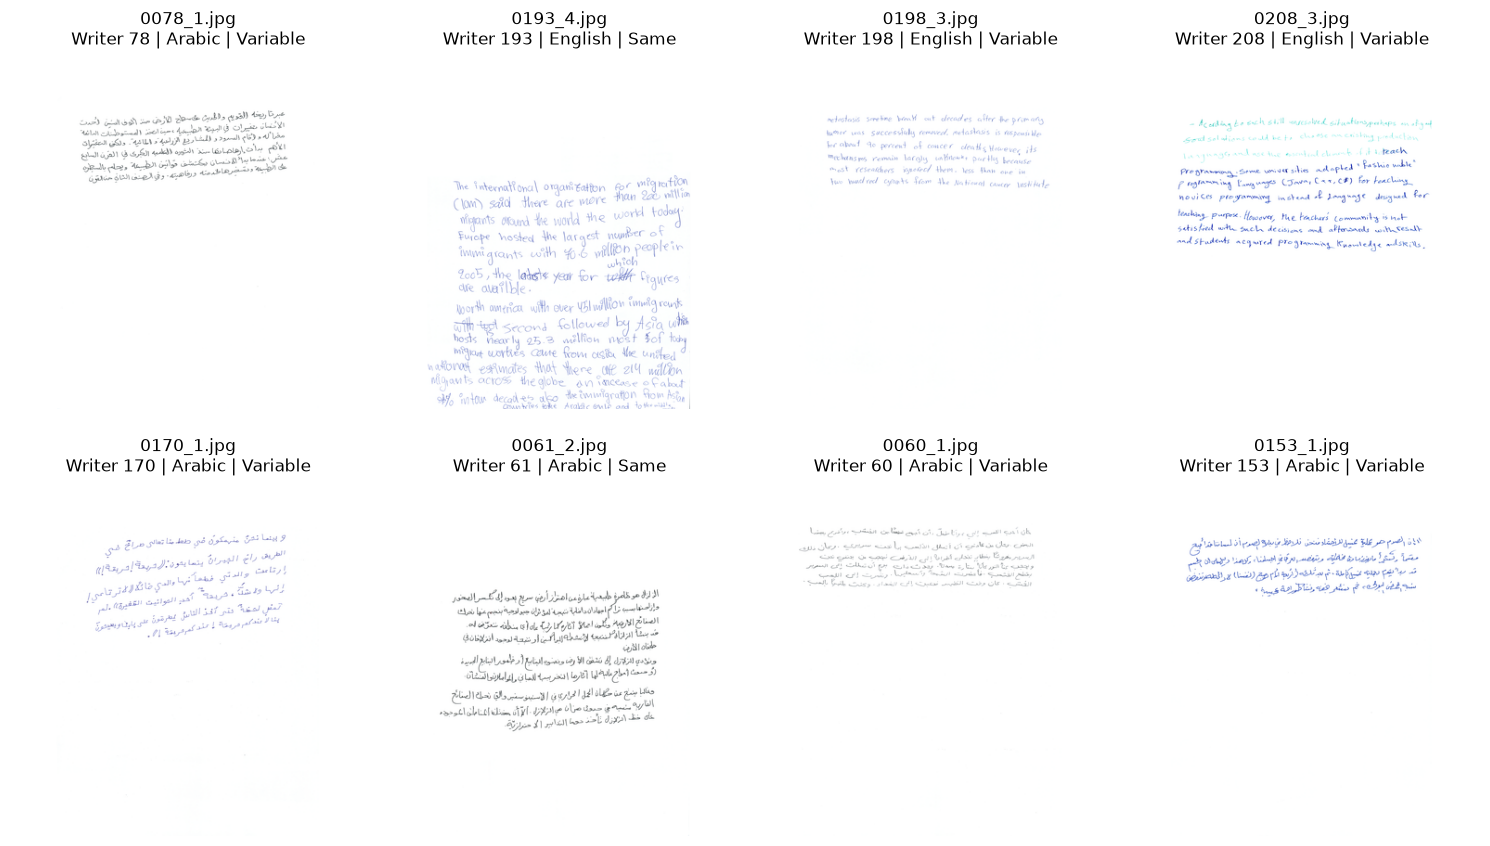

In [9]:
figure, axes = plt.subplots(2, 4, figsize=(15, 9))

for index, axis in enumerate(axes.flat):
    image = train_batch["image"][index].permute(1, 2, 0).numpy()

    language = train_batch["language"][index]
    same_text = train_batch["same_text"][index].item()
    text_condition = "Same" if same_text == 1 else "Variable"

    axis.imshow(image)
    axis.set_title(
        f"{train_batch['filename'][index]}\n"
        f"Writer {train_batch['writer_id'][index].item()} | "
        f"{language} | {text_condition}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [10]:
validation_batch = next(iter(validation_loader))
test_batch = next(iter(test_loader))

print("Validation batch shape:", validation_batch["image"].shape)
print("Validation filenames:", validation_batch["filename"])
print("Validation writer IDs:", validation_batch["writer_id"].tolist())

print("\nTest batch shape:", test_batch["image"].shape)
print("Test filenames:", test_batch["filename"])
print("Test writer IDs:", test_batch["writer_id"].tolist())

assert validation_batch["image"].shape == (8, 3, 384, 384)
assert test_batch["image"].shape == (8, 3, 384, 384)
assert set(validation_batch["writer_id"].tolist()).issubset(validation_writers)
assert set(test_batch["writer_id"].tolist()).issubset(test_writers)

Validation batch shape: torch.Size([8, 3, 384, 384])
Validation filenames: ['0004_1.jpg', '0004_2.jpg', '0004_3.jpg', '0004_4.jpg', '0013_1.jpg', '0013_2.jpg', '0013_3.jpg', '0013_4.jpg']
Validation writer IDs: [4, 4, 4, 4, 13, 13, 13, 13]

Test batch shape: torch.Size([8, 3, 384, 384])
Test filenames: ['0283_1.jpg', '0283_2.jpg', '0283_3.jpg', '0283_4.jpg', '0284_1.jpg', '0284_2.jpg', '0284_3.jpg', '0284_4.jpg']
Test writer IDs: [283, 283, 283, 283, 284, 284, 284, 284]


In [11]:
def audit_loader(loader):
    total_samples = 0
    writer_ids = set()
    tensor_shapes = set()
    language_counts = torch.zeros(2, dtype=torch.long)
    text_condition_counts = torch.zeros(2, dtype=torch.long)
    page_counts = torch.zeros(5, dtype=torch.long)

    for batch in loader:
        images = batch["image"]

        assert torch.isfinite(images).all()

        total_samples += images.shape[0]
        writer_ids.update(batch["writer_id"].tolist())
        tensor_shapes.add(tuple(images.shape[1:]))

        language_counts += torch.bincount(
            batch["language_label"],
            minlength=2,
        )

        text_condition_counts += torch.bincount(
            batch["same_text"],
            minlength=2,
        )

        page_counts += torch.bincount(
            batch["page_id"],
            minlength=5,
        )

    return {
        "samples": total_samples,
        "writers": len(writer_ids),
        "tensor_shapes": tensor_shapes,
        "language_counts": {
            "Arabic": language_counts[0].item(),
            "English": language_counts[1].item(),
        },
        "text_condition_counts": {
            "variable": text_condition_counts[0].item(),
            "same": text_condition_counts[1].item(),
        },
        "page_counts": {
            page_id: page_counts[page_id].item()
            for page_id in range(1, 5)
        },
    }


loader_audits = {
    "development_train": audit_loader(train_loader),
    "validation": audit_loader(validation_loader),
    "official_test": audit_loader(test_loader),
}

for split_name, audit in loader_audits.items():
    print(f"\n{split_name}")
    for key, value in audit.items():
        print(f"{key}: {value}")


development_train
samples: 904
writers: 226
tensor_shapes: {(3, 384, 384)}
language_counts: {'Arabic': 452, 'English': 452}
text_condition_counts: {'variable': 452, 'same': 452}
page_counts: {1: 226, 2: 226, 3: 226, 4: 226}

validation
samples: 224
writers: 56
tensor_shapes: {(3, 384, 384)}
language_counts: {'Arabic': 112, 'English': 112}
text_condition_counts: {'variable': 112, 'same': 112}
page_counts: {1: 56, 2: 56, 3: 56, 4: 56}

official_test
samples: 772
writers: 193
tensor_shapes: {(3, 384, 384)}
language_counts: {'Arabic': 386, 'English': 386}
text_condition_counts: {'variable': 386, 'same': 386}
page_counts: {1: 193, 2: 193, 3: 193, 4: 193}


In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

gpu_images = train_batch["image"].to(
    device,
    non_blocking=True,
)

if device.type == "cuda":
    torch.cuda.synchronize()
    peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )
else:
    peak_memory_mb = 0.0

batch_memory_mb = (
    gpu_images.numel()
    * gpu_images.element_size()
    / 1024**2
)

print("Device:", device)
print("GPU batch shape:", gpu_images.shape)
print("Batch tensor memory:", round(batch_memory_mb, 2), "MB")
print("Peak allocated memory:", round(peak_memory_mb, 2), "MB")
print("Finite values:", torch.isfinite(gpu_images).all().item())

assert gpu_images.shape == (8, 3, 384, 384)
assert torch.isfinite(gpu_images).all()

Device: cuda
GPU batch shape: torch.Size([8, 3, 384, 384])
Batch tensor memory: 13.5 MB
Peak allocated memory: 14.0 MB
Finite values: True


In [13]:
REPORT_DIR = PROJECT_ROOT / "reports" / "dataloader"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

serializable_audits = {}

for split_name, audit in loader_audits.items():
    serializable_audits[split_name] = {
        "samples": audit["samples"],
        "writers": audit["writers"],
        "tensor_shapes": [
            list(shape)
            for shape in sorted(audit["tensor_shapes"])
        ],
        "language_counts": audit["language_counts"],
        "text_condition_counts": audit["text_condition_counts"],
        "page_counts": {
            str(key): value
            for key, value in audit["page_counts"].items()
        },
    }

dataloader_report = {
    "dataset": "QUWI",
    "target_size": list(TARGET_SIZE),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "shuffle_training": True,
    "shuffle_validation": False,
    "shuffle_test": False,
    "pin_memory": torch.cuda.is_available(),
    "random_seed": 42,
    "device_tested": str(device),
    "batch_tensor_memory_mb": batch_memory_mb,
    "peak_gpu_memory_mb": peak_memory_mb,
    "language_labels": LANGUAGE_TO_LABEL,
    "splits": serializable_audits,
}

report_path = REPORT_DIR / "quwi_dataloader_audit.json"

with report_path.open("w", encoding="utf-8") as file:
    json.dump(
        dataloader_report,
        file,
        indent=2,
    )

print("Report path:", report_path)
print("Batch size:", dataloader_report["batch_size"])
print("Number of workers:", dataloader_report["num_workers"])
print("Device tested:", dataloader_report["device_tested"])
print("Saved splits:", list(dataloader_report["splits"]))

Report path: /home/arijit/Documents/handwriting-cross-script-research/reports/dataloader/quwi_dataloader_audit.json
Batch size: 8
Number of workers: 0
Device tested: cuda
Saved splits: ['development_train', 'validation', 'official_test']


In [14]:
with report_path.open("r", encoding="utf-8") as file:
    saved_dataloader_report = json.load(file)

print("Dataset:", saved_dataloader_report["dataset"])
print("Target size:", saved_dataloader_report["target_size"])
print("Batch size:", saved_dataloader_report["batch_size"])
print("Device tested:", saved_dataloader_report["device_tested"])

for split_name, split_report in saved_dataloader_report["splits"].items():
    print(
        split_name,
        "samples:",
        split_report["samples"],
        "writers:",
        split_report["writers"],
        "shapes:",
        split_report["tensor_shapes"],
    )

assert saved_dataloader_report["dataset"] == "QUWI"
assert saved_dataloader_report["target_size"] == [384, 384]
assert saved_dataloader_report["batch_size"] == 8
assert saved_dataloader_report["splits"]["development_train"]["samples"] == 904
assert saved_dataloader_report["splits"]["validation"]["samples"] == 224
assert saved_dataloader_report["splits"]["official_test"]["samples"] == 772

Dataset: QUWI
Target size: [384, 384]
Batch size: 8
Device tested: cuda
development_train samples: 904 writers: 226 shapes: [[3, 384, 384]]
validation samples: 224 writers: 56 shapes: [[3, 384, 384]]
official_test samples: 772 writers: 193 shapes: [[3, 384, 384]]


## Dataset and DataLoader conclusion

A custom PyTorch Dataset was created for QUWI using the validated RGB preprocessing pipeline. Each sample returns:

- A `3 × 384 × 384` float32 image tensor
- Writer ID
- Page ID
- Script label
- Same-text label
- Filename
- Experiment-split metadata

Separate DataLoaders were constructed for the development-training, validation, and official-test splits. Writer identities remain fully disjoint across all three splits.

All 1,900 images were loaded successfully with finite tensor values and identical tensor shapes. The script, text-condition, and page distributions remain balanced within every split.

A batch size of 8 was successfully transferred to the NVIDIA RTX 3050 Laptop GPU. The image tensor occupied approximately 13.5 MB, although complete model training will require additional memory for network activations, gradients, and optimizer states.

The current DataLoader configuration uses zero worker processes for maximum notebook stability. Worker count and batch size will be tuned later during baseline-model benchmarking.

Generated file:

- `reports/dataloader/quwi_dataloader_audit.json`

The next stage is to move the validated Dataset and preprocessing logic into reusable source modules before beginning the first baseline model.